# 문제 2 코로나19 C1 · C2 (v2): 입원(ARI)과 SARI를 함께 예측

인플루엔자(`flu_hosp`)처럼 **같은 시나리오 변이 점유율 경로를 공유하는 두 번째 지표**를 추가했습니다. 기점 2026-39에서 2026-40 ~ 2027-35(49주)를 예측합니다.
- `covid_ari`: 코로나19 입원환자 수, 급성호흡기감염증 입원환자 표본감시 — 학습 자료의 **ARI 열** (필수)
- `covid_sari`: 중증급성호흡기감염증 표본감시 건수 — 학습 자료의 **SARI 열** (선택)

**이 노트북(v2)에서 바뀐 점** (이전 `Problem2_C1_C2_covid.ipynb`(v3 코드) 대비)
- 시나리오(C1 · C2 · REP)의 **변이 점유율 경로와 모형 구조는 그대로**입니다. 사용처가 없는 기본 예측(BASE)은 **제거**했습니다. 점유율 경로 1,000개마다 ARI 경로와 SARI 경로를 각각 만듭니다.
- 지표마다 수준 모형(Ridge+ET)과 AR(1) 오차를 **따로 학습**합니다(`phi`, 기점 직전 오차 `e0`가 지표마다 다름).
- 백테스트로 고르는 모형과 오차 크기(`sinf`)는 **ARI 기준**으로 한 번만 고르고 SARI에도 같게 씁니다. 인플루엔자 코드가 입원(ARI)에 ILI의 선택을 그대로 쓰는 것과 같은 방식이며, SARI 자체의 백테스트는 하지 않았습니다.
- REP(C1 0.5 : C2 0.5)는 C1 경로와 C2 경로를 그대로 합친 **균등 혼합**입니다(각 1,000개 -> 2,000개, 가중치 정확히 1/2씩). ARI와 SARI 모두 같은 방식입니다.
- 따라서 REP 행만 이전 결과(`results_v3`, 경로마다 시나리오를 무작위로 뽑아 C2 비율이 0.511이었음)와 조금 다릅니다.
- C1 · C2의 ARI 결과는 이전 코드와 같은 난수 씨앗을 써서 **이전 결과(`results_v3`)와 같은 값**이 나옵니다.
- 결과는 `results_v2`에 저장합니다. 시계열·단일값 표의 `target` 열이 `covid_ari` / `covid_sari`입니다.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
import json
from datetime import date, timedelta
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Image

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#555555', 'axes.labelcolor': '#222222', 'xtick.color': '#444444', 'ytick.color': '#444444',
                     'axes.grid': False, 'grid.color': '#E6E6E6', 'grid.linewidth': 0.8, 'figure.dpi': 110, 'savefig.dpi': 220})

SEED = 2026
QUANTILES = np.array([0.025, 0.10, 0.25, 0.50, 0.75, 0.90, 0.975])
QCOLS = ['q0.025', 'q0.10', 'q0.25', 'q0.50', 'q0.75', 'q0.90', 'q0.975']
DATA_PATH = '코로나19 2차 학습 데이터.xlsx'
VARIANT_PATH = '2020-2026.8 코로나19 변이바이러스 점유율 현황.xlsx'
RESULT_DIR = Path('results_v2')
RESULT_DIR.mkdir(exist_ok=True)

ORIGIN = 202639
TARGETS = {'covid_ari': 'ARI', 'covid_sari': 'SARI'}   # 예측 지표 → 학습 자료의 열
N_STEPS = 49
N_PATHS = 1000
LAST_SHARE_MONTH = (2026, 8)       # 변이 점유율 자료의 마지막 달
TIMING_JITTER = 2                  # "전후" = ±2주 (인플루엔자와 동일, 균등 5가지)
C2_T50_WEEK = 202650               # C2: 신규 변이 점유율 50% 도달 주 (±2주)
EVENT_LINEAGES = ['JN.1', 'KP.3', 'NB.1.8.1', 'BA.3.2', 'PQ.16.1.1']   # C2 상승 속도를 구하는 교체 사건 5건
ANALOG_FIRST = '2021-07'           # 분석 계통: 이 달 이후 처음 50%가 된 계통 (델타부터)
ARRIVAL_SHARE = 0.20               # "신규 변이 도착": 우세 당시 5% 미만이던 단일 계통이 20% 이상이 된 달
CURVE_NOISE = 0.07                 # 곡선마다 곱하는 작은 오차(로그 표준편차)
PQ_MAX = 0.97                      # 점유율 상한(합이 100%를 넘지 않게)
CANDIDATE_SETS = {'Ridge': ['Ridge'], 'ET': ['ET'], 'Ridge+ET': ['Ridge', 'ET']}
SINF_GRID = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2]   # 오차의 장기 표준편차(로그 척도) 후보
AR_PHI_MAX = 0.90                  # AR(1) 계수 상한: 자료가 짧아 추정값이 0.89~0.96로 흔들려 0.90으로 제한
N_BT = 300                         # 백테스트 경로 수
BACKTEST_STEP = 6
COL = {'C1': '#1F4E9C', 'C2': '#C2185B', 'REP': '#6A4C93', 'obs': '#222222', 'PQ': '#E69F00', 'BA32': '#0072B2', 'NB': '#009E73', 'NEW': '#C2185B', 'OTHER': '#B8B8B8'}

WEEKS_IN_YEAR = {2023: 52, 2024: 52, 2025: 52, 2026: 53, 2027: 52, 2028: 52}
YEAR_ANCHOR = {2023: date(2023, 1, 1), 2024: date(2023, 12, 31), 2025: date(2024, 12, 29), 2026: date(2025, 12, 28), 2027: date(2027, 1, 3)}  # 각 해 1주 시작일(일요일)


def week_list(first, last):
    out, y, w = [], first // 100, first % 100
    while y * 100 + w <= last:
        out.append(y * 100 + w)
        w += 1
        if w > WEEKS_IN_YEAR[y]:
            y, w = y + 1, 1
    return out


def week_mid(yw):
    y, w = divmod(yw, 100)
    return YEAR_ANCHOR[y] + timedelta(days=7 * (w - 1) + 3)


def next_weeks(origin, count):
    return [f'{v // 100}-{v % 100:02d}' for v in week_list(origin, origin + 200)[1:count + 1]]


def wis(q, actual):
    score = 0.5 * np.abs(actual - q[:, 3])
    for alpha, lo, hi in [(0.05, 0, 6), (0.20, 1, 5), (0.50, 2, 4)]:
        l, u = q[:, lo], q[:, hi]
        score += alpha / 2 * (u - l + 2 / alpha * np.maximum(l - actual, 0) + 2 / alpha * np.maximum(actual - u, 0))
    return score / 3.5


# ---------- 자료 ----------
def load_ari(path):
    d = pd.read_excel(path)
    d.columns = ['년도', '주차', '년주', 'ARI', 'SARI']
    d = d.sort_values('년주').reset_index(drop=True)
    assert d['년주'].is_unique and d['ARI'].notna().all() and d['SARI'].notna().all()
    return d


def load_variants(path):
    """월별 점유율(%) 표 → (월 리스트, 계통 이름, 행렬 (월, 계통))."""
    v = pd.read_excel(path, header=None)
    names = [str(x) for x in v.iloc[2:, 0]]
    months, y = [], None
    for j in range(1, v.shape[1]):
        if isinstance(v.iloc[0, j], str) and '년' in v.iloc[0, j]:
            y = int(v.iloc[0, j].replace('년', ''))
        months.append((y, int(str(v.iloc[1, j]).replace('월', ''))))
    M = v.iloc[2:, 1:].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float).T
    M = M / np.maximum(M.sum(axis=1, keepdims=True), 1e-9)
    return months, names, M


ari, = [load_ari(DATA_PATH)]
months, names, M = load_variants(VARIANT_PATH)
assert months[-1] == LAST_SHARE_MONTH
timeline = week_list(202301, 202735)
t_hist = timeline.index(ORIGIN) + 1
month_t = np.array([(date(y, m, 15) - date(2020, 1, 1)).days for y, m in months])


def weekly_shares(M):
    """월 중간(15일)에 월 점유율을 놓고 선형 보간한 주별 점유율 (주, 계통). 마지막 달 이후는 마지막 값을 유지."""
    days = np.array([(week_mid(w) - date(2020, 1, 1)).days for w in timeline])
    S = np.stack([np.interp(days, month_t, M[:, k]) for k in range(M.shape[1])], axis=1)
    return S / np.maximum(S.sum(axis=1, keepdims=True), 1e-9)


S_all = weekly_shares(M)
S_hist = S_all[:t_hist]                   # 기점까지
train = ari.loc[ari['년주'] <= ORIGIN].copy().reset_index(drop=True)
assert train['년주'].iloc[-1] == ORIGIN
idx0 = timeline.index(int(train['년주'].iloc[0]))
print('학습 기간', train['년주'].iloc[0], '~', ORIGIN, f'({len(train)}주), 변이 점유율 마지막 달 {LAST_SHARE_MONTH}')
aug = dict(zip(names, np.round(M[-1] * 100, 1)))
print('2026-08 점유율(%):', {k: v for k, v in aug.items() if v > 0})

학습 기간 202401 ~ 202639 (143주), 변이 점유율 마지막 달 (2026, 8)
2026-08 점유율(%): {'NB.1.8.1': np.float64(19.7), 'BA.3.2': np.float64(15.8), 'PQ.16.1.1': np.float64(53.9), 'RF.5': np.float64(5.3), '기타': np.float64(5.3)}


## 1. 입력 특성과 모형 (인플루엔자와 같은 구조; 오차 산출용 교차검증만 26주 블록으로 변경)
변이 점유율 행렬 `S`(주 × 계통)에서 4개 특성을 만듭니다. 시나리오에서는 신규 계통 열 하나를 더해 같은 식으로 계산합니다.

In [2]:
FEATURES = ['dom', 'new12', 'turn4', 'turn12', 'sin1', 'cos1', 'sin2', 'cos2']


def share_design(S, wk):
    """S: (N, T, L) 주별 점유율(0~1), wk: (T,) 주차 → (N, T-12, 8): t = 12..T-1."""
    cur = S[:, 12:]
    dom = cur.max(axis=2)
    new12 = (cur * (S[:, :-12] < 0.05)).sum(axis=2)
    turn4 = 0.5 * np.abs(cur - S[:, 8:-4]).sum(axis=2)
    turn12 = 0.5 * np.abs(cur - S[:, :-12]).sum(axis=2)
    ang = 2 * np.pi * np.asarray(wk, float)[12:] / 52.18
    N = S.shape[0]
    tile = lambda f: np.broadcast_to(f(ang)[None], (N, len(ang)))
    return np.stack([dom, new12, turn4, turn12, tile(np.sin), tile(np.cos), tile(lambda a: np.sin(2 * a)), tile(lambda a: np.cos(2 * a))], axis=2)


def season_of(yw):
    y, w = divmod(int(yw), 100)
    return y if w >= 36 else y - 1


def make_member(name):
    if name == 'Ridge':
        return make_pipeline(StandardScaler(), Ridge(alpha=3.0))
    return ExtraTreesRegressor(n_estimators=200, min_samples_leaf=3, max_features=0.7, random_state=SEED, n_jobs=1)


def wk_of(yws):
    return np.array([v % 100 for v in yws], float)


def training_table(df, S, col='ARI'):
    """학습 행: 점유율 특성(과거 12주 필요), 로그 ARI, 절기."""
    i0 = timeline.index(int(df['년주'].iloc[0]))
    n = len(df)
    X = share_design(S[None, i0 - 12:i0 + n], wk_of(timeline[i0 - 12:i0 + n]))[0]
    y = np.log1p(df[col].to_numpy(float))
    return X, y, np.ones(n, bool), np.arange(n) // 26      # 교차검증 묶음: 연속 26주 블록(자료가 짧아 절기 단위 대신 사용)


def fit_level(X, y, members):
    return {m: make_member(m).fit(X, y) for m in members}


def loso(X, y, ok, season, members):
    pred = {m: np.full(len(y), np.nan) for m in members}
    for s in np.unique(season):
        te, tr = season == s, season != s
        if tr.sum() < 20:
            continue
        mods = fit_level(X[tr], y[tr], members)
        for m in members:
            pred[m][te] = mods[m].predict(X[te])
    return pred


def ar_fit(e):
    a, b = e[:-1], e[1:]
    good = np.isfinite(a) & np.isfinite(b)
    phi = float(np.clip(np.sum(a[good] * b[good]) / np.sum(a[good] ** 2), 0.0, AR_PHI_MAX))
    eps = b[good] - phi * a[good]
    return phi, eps - np.median(eps)


def fit_forecaster(df, S, col='ARI'):
    members = ['Ridge', 'ET']
    X, y, ok, season = training_table(df, S, col)
    return {'models': fit_level(X, y, members), 'loso': loso(X, y, ok, season, members), 'y': y}


def candidate_state(fc, cand):
    pred = np.mean([fc['loso'][m] for m in CANDIDATE_SETS[cand]], axis=0)
    e = fc['y'] - pred
    phi, eps = ar_fit(e)
    return phi, eps, (float(e[-1]) if np.isfinite(e[-1]) else 0.0)


def simulate(fc, cand, F, phi, eps, e0, scale, rng, n_paths=None):
    """F: (N, T, d) 미래 특성. 반환 (N, T) ARI 경로."""
    N, T, d = F.shape
    f = np.mean([fc['models'][m].predict(F.reshape(-1, d)).reshape(N, T) for m in CANDIDATE_SETS[cand]], axis=0)
    if n_paths is not None and N == 1:
        f, N = np.repeat(f, n_paths, axis=0), n_paths
    e = np.full(N, e0)
    out = np.empty((N, T))
    for k in range(T):
        e = phi * e + scale * rng.choice(eps, size=N)
        out[:, k] = np.expm1(f[:, k] + e)
    return np.maximum(out, 0)

## 2. 오차 모형과 롤링 백테스트 (기준모형 혼합 없음)
v2까지는 모형 경로에 부록 B 기준모형 경로를 섞었는데, 기준모형의 변화량 분포가 너무 넓어 95% 구간 상단이 매우 컸습니다. v3에서는 **섞지 않고** 모형 하나로 예측합니다.
- 예측 = 수준 모형 `f` (변이 점유율 지표 + 계절) + 오차 `e`.
- 오차의 **평균 부분**: 기점 직전 오차 `e0`가 `phi`씩 줄며 이어짐(결정적 보정, 예측선이 관측선에서 튀지 않게 함).
- 오차의 **임의 부분**: AR(1) 임의 오차이며 장기 표준편차 `sinf`(로그 척도) 하나로 크기를 정함. 지평 h에서의 표준편차는 `sinf × sqrt(1 − phi^(2h))`.
- `sinf`와 모형은 과거 14개 기점의 백테스트(실제 변이 점유율을 조건으로 최대 49주 앞 예측) WIS가 가장 작은 값으로 고릅니다. 평가 기준모형은 부록 B 그대로입니다.

backtest 1/14 (origin 202501)


backtest 2/14 (origin 202507)


backtest 3/14 (origin 202513)


backtest 4/14 (origin 202519)


backtest 5/14 (origin 202525)


...

backtest 13/14 (origin 202621)


backtest 14/14 (origin 202627)


,model,sinf,WIS,MAE,cov95,cov50,relative_WIS_vs_baseline
0,Ridge+ET,0.8,62.159,110.793,0.788,0.246,0.845
1,Ridge+ET,0.7,63.552,114.830,0.685,0.193,0.864
2,Ridge+ET,0.6,63.718,112.989,0.580,0.154,0.866
3,Ridge,0.7,65.092,114.230,0.665,0.224,0.885
4,ET,0.7,66.080,120.008,0.700,0.177,0.898
5,Ridge,0.8,66.139,114.146,0.754,0.253,0.899
6,ET,0.8,66.313,120.093,0.808,0.212,0.901
7,Ridge+ET,0.5,66.321,112.935,0.485,0.121,0.901
8,ET,0.6,66.330,117.980,0.593,0.165,0.902
9,Ridge,0.6,67.225,115.062,0.566,0.179,0.914


선택: Ridge+ET (장기 오차 sd = 0.8) | 기준모형 대비 상대 WIS 0.845, 95% 구간 포함률 0.79, 50% 구간 포함률 0.25
전체 상대 WIS = 0.845


,band,모형 WIS,기준모형 WIS,상대 WIS
0,1-5주,35.605,31.024,1.148
1,6-15주,65.718,69.527,0.945
2,16-30주,67.041,77.259,0.868
3,31-49주,65.159,90.626,0.719


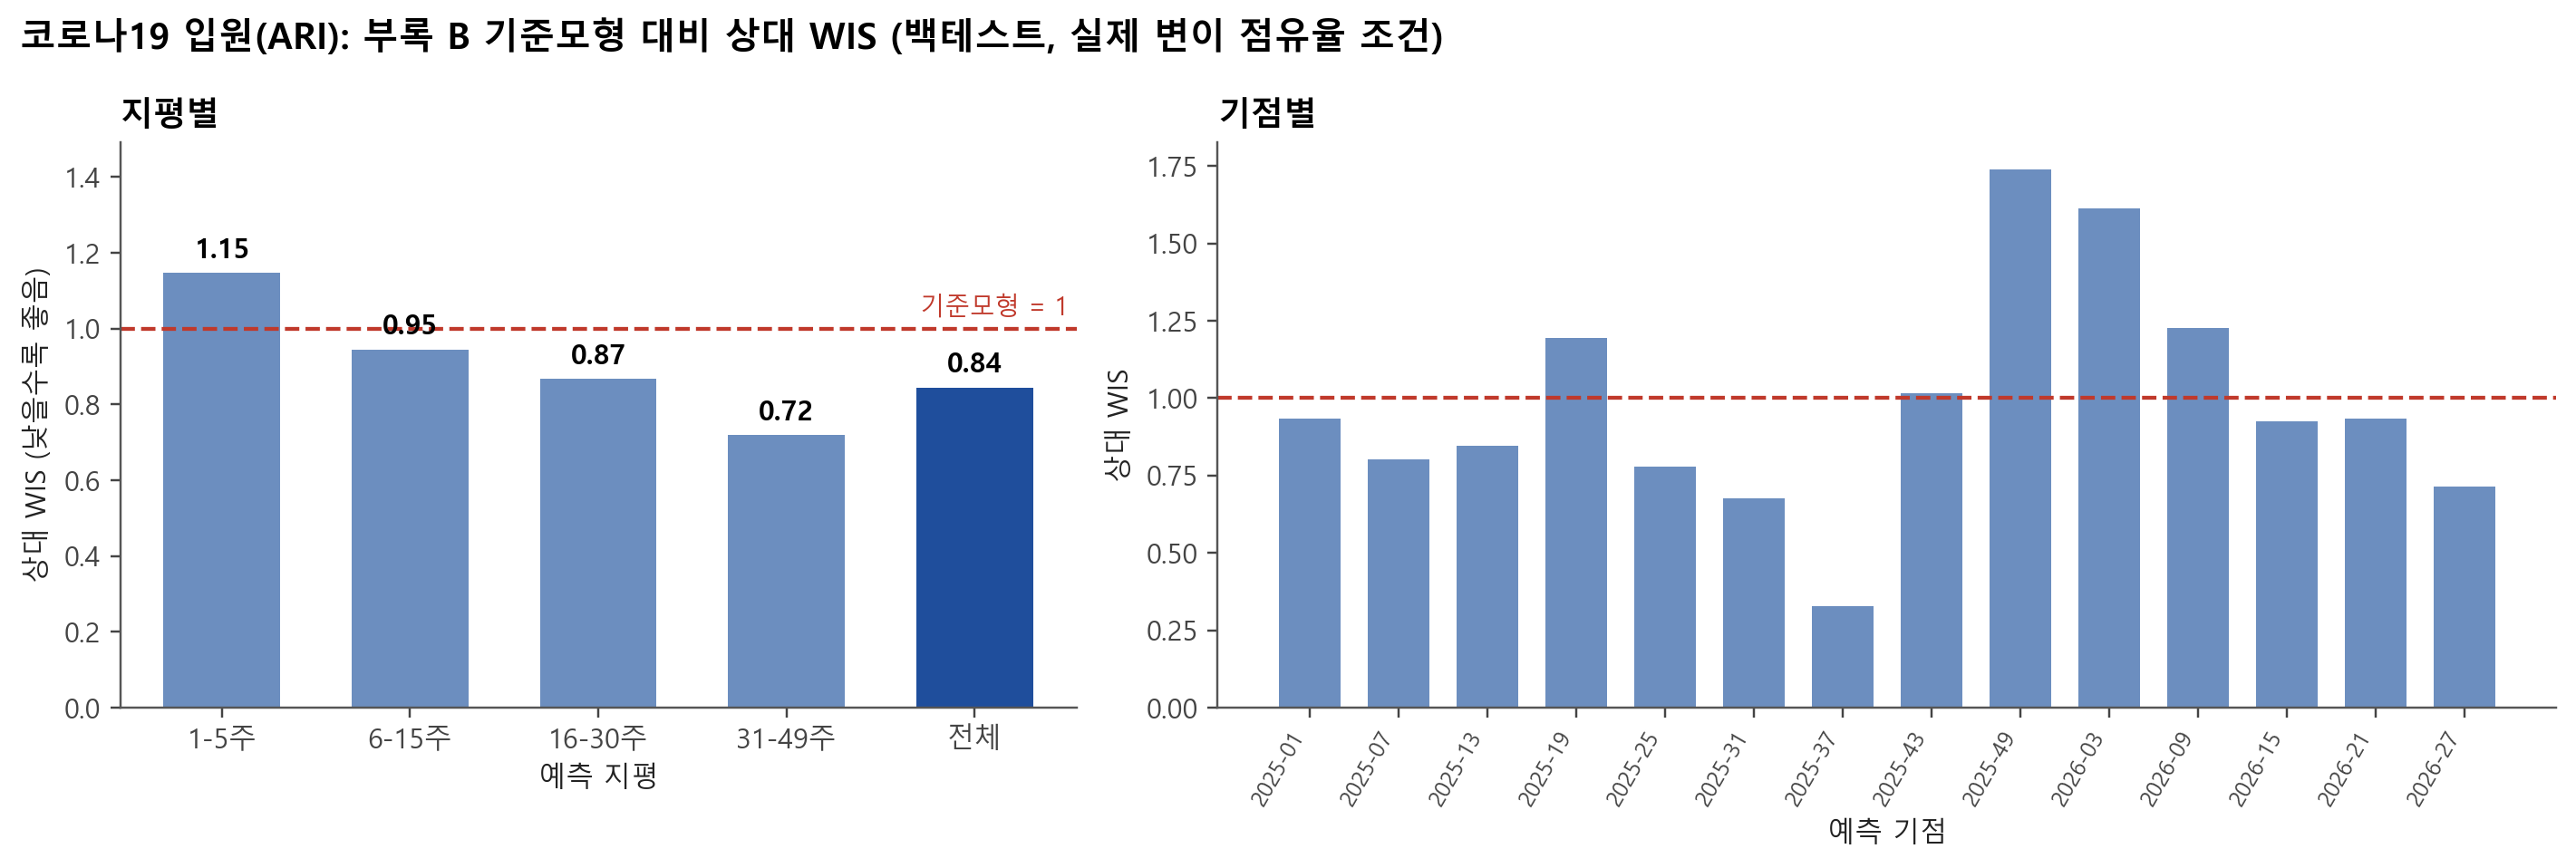

In [3]:
def baseline_quantiles(hist, T):
    yy = hist['ARI'].to_numpy(float)
    out = []
    for h in range(1, T + 1):
        change = yy[h:] - yy[:-h]
        change = np.r_[change, -change]
        out.append(np.maximum(0, yy[-1] + np.quantile(change, QUANTILES)))
    return np.asarray(out)


def simulate_ar(fc, cand, F, phi, e0, sinf, rng, n_paths=None):
    """F: (N, T, d) 미래 특성 → (N, T) ARI 경로.  log1p(ARI) = f + e0·phi^h + AR(1) 임의 오차(장기 sd = sinf)."""
    N, T, d = F.shape
    f = np.mean([fc['models'][m].predict(F.reshape(-1, d)).reshape(N, T) for m in CANDIDATE_SETS[cand]], axis=0)
    if n_paths is not None and N == 1:
        f, N = np.repeat(f, n_paths, axis=0), n_paths
    det = e0 * phi ** np.arange(1, T + 1)
    stoch = np.zeros(N)
    out = np.empty((N, T))
    for k in range(T):
        stoch = phi * stoch + np.sqrt(1 - phi ** 2) * sinf * rng.standard_normal(N)
        out[:, k] = np.expm1(f[:, k] + det[k] + stoch)
    return np.maximum(out, 0)


def backtest(df, S, step=BACKTEST_STEP, horizon=N_STEPS):
    rng = np.random.default_rng(SEED)
    first = int(np.flatnonzero(df['년주'].to_numpy() == 202501)[0])
    origins = list(range(first, len(df) - 8, step))
    rows = []

    def add(origin, name, sinf, t_idx, q, a):
        rows.append({'origin': origin, 'model': name, 'sinf': sinf, 'h': int(t_idx + 1), 'WIS': float(wis(q[t_idx:t_idx + 1], a[t_idx:t_idx + 1])[0]),
                     'abs_err': abs(q[t_idx, 3] - a[t_idx]), 'cov95': float(q[t_idx, 0] <= a[t_idx] <= q[t_idx, 6]), 'cov50': float(q[t_idx, 2] <= a[t_idx] <= q[t_idx, 4])})

    for n_o, i0 in enumerate(origins):
        hist = df.iloc[:i0 + 1]
        T = min(horizon, len(df) - 1 - i0)
        actual = df.iloc[i0 + 1:i0 + 1 + T]['ARI'].to_numpy(float)
        origin = int(df['년주'].iloc[i0])
        t_o = timeline.index(origin)
        F = share_design(S[None, t_o + 1 - 12:t_o + 1 + T], wk_of(timeline[t_o + 1 - 12:t_o + 1 + T]))[:, -T:]
        fc = fit_forecaster(hist, S)
        q = baseline_quantiles(hist, T)
        for t_idx in range(T):
            add(origin, 'Baseline', np.nan, t_idx, q, actual)
        for cand in CANDIDATE_SETS:
            phi, eps, e0 = candidate_state(fc, cand)
            for sinf in SINF_GRID:
                q = np.quantile(simulate_ar(fc, cand, F, phi, e0, sinf, rng, n_paths=N_BT), QUANTILES, axis=0).T
                for t_idx in range(T):
                    add(origin, cand, sinf, t_idx, q, actual)
        print(f'backtest {n_o + 1}/{len(origins)} (origin {origin})', flush=True)
    return pd.DataFrame(rows)


bt = backtest(train, S_all)
bt.to_csv(RESULT_DIR / 'backtest_by_step.csv', index=False)
bt['band'] = pd.cut(bt['h'], [0, 5, 15, 30, 49], labels=['1-5주', '6-15주', '16-30주', '31-49주'])
summary = bt.groupby(['model', 'sinf'], dropna=False).agg(WIS=('WIS', 'mean'), MAE=('abs_err', 'mean'), cov95=('cov95', 'mean'), cov50=('cov50', 'mean')).reset_index()
base_wis = float(summary.loc[summary['model'] == 'Baseline', 'WIS'].iloc[0])
summary['relative_WIS_vs_baseline'] = summary['WIS'] / base_wis
summary = summary.sort_values('WIS').reset_index(drop=True)
summary.to_csv(RESULT_DIR / 'backtest_summary.csv', index=False)
display(summary.round(3).head(10))
best = summary.loc[summary['model'] != 'Baseline'].iloc[0]
BEST_MODEL, BEST_SINF = str(best['model']), float(best['sinf'])
print(f'선택: {BEST_MODEL} (장기 오차 sd = {BEST_SINF}) | 기준모형 대비 상대 WIS {best["relative_WIS_vs_baseline"]:.3f}, 95% 구간 포함률 {best["cov95"]:.2f}, 50% 구간 포함률 {best["cov50"]:.2f}')

sel, base_df = bt[(bt['model'] == BEST_MODEL) & (bt['sinf'] == BEST_SINF)], bt[bt['model'] == 'Baseline']


def rel_table(col):
    a, b = (g.groupby(col, observed=True)['WIS'].mean() for g in (sel, base_df))
    return pd.DataFrame({'모형 WIS': a, '기준모형 WIS': b, '상대 WIS': a / b}).reset_index()


rel_band, rel_origin = rel_table('band'), rel_table('origin')
rel_total = float(sel['WIS'].mean() / base_df['WIS'].mean())
rel_band.to_csv(RESULT_DIR / 'relative_WIS_by_horizon.csv', index=False)
rel_origin.to_csv(RESULT_DIR / 'relative_WIS_by_origin.csv', index=False)
print(f'전체 상대 WIS = {rel_total:.3f}')
display(rel_band.round(3))


def relative_wis_figure(rel_band, rel_origin, rel_total, path, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={'width_ratios': [1, 1.4]})
    ax = axes[0]
    labels_b = list(rel_band.iloc[:, 0].astype(str)) + ['전체']
    vals = list(rel_band['상대 WIS']) + [rel_total]
    bars = ax.bar(labels_b, vals, color=['#6C8EBF'] * len(rel_band) + ['#1F4E9C'], width=0.62)
    ax.bar_label(bars, labels=[f'{v:.2f}' for v in vals], padding=3, fontsize=10, fontweight='bold')
    ax.axhline(1.0, color='#C0392B', linestyle='--', linewidth=1.4)
    ax.text(len(vals) - 0.5, 1.02, '기준모형 = 1', color='#C0392B', ha='right', va='bottom', fontsize=9)
    ax.set_ylim(0, max(vals + [1.0]) * 1.3)
    ax.set_xlabel('예측 지평'); ax.set_ylabel('상대 WIS (낮을수록 좋음)')
    ax.set_title('지평별', loc='left', fontweight='bold')
    ax = axes[1]
    ob = [f'{int(o) // 100}-{int(o) % 100:02d}' for o in rel_origin.iloc[:, 0]]
    ax.bar(ob, rel_origin['상대 WIS'], color='#6C8EBF', width=0.7)
    ax.axhline(1.0, color='#C0392B', linestyle='--', linewidth=1.4)
    ax.set_xticks(range(len(ob)), ob, rotation=60, ha='right', fontsize=8)
    ax.set_xlabel('예측 기점'); ax.set_ylabel('상대 WIS')
    ax.set_title('기점별', loc='left', fontweight='bold')
    fig.suptitle(title, x=0.01, ha='left', fontsize=13, fontweight='bold')
    fig.tight_layout()
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)


relative_wis_figure(rel_band, rel_origin, rel_total, RESULT_DIR / 'relative_WIS_vs_baseline.png', '코로나19 입원(ARI): 부록 B 기준모형 대비 상대 WIS (백테스트, 실제 변이 점유율 조건)')
display(Image(filename=str(RESULT_DIR / 'relative_WIS_vs_baseline.png')))

## 3. 변이 점유율 경로: 과거 우세 변이 10개의 패턴에서 만듭니다
**과거 우세 변이(분석 계통)**: 2021-07 이후 월 점유율이 처음 50% 이상이 된 계통 중, 그 후 13개월 이상 자료가 있는 10개(델타, BA.1, BA.2, BA.5, BN.1, XBB, HK.3, JN.1, KP.3, NB.1.8.1). 50% 이상이 된 첫 달을 **0개월**로 두고, 매달 점유율이 0개월 값의 몇 배인지(**비율 곡선**)를 계산합니다.

**"신규 변이 도착"의 정의**: 그 계통이 우세해질 때 5% 미만이던 계통 중 **단일 계통이 20% 이상**이 된 달. 그 직전까지가 "신규 변이가 들어오기 전(자연 구간)"입니다.

| 시나리오 | 쓰는 비율 곡선 | PQ.16.1.1 점유율 | 남는 점유율 |
|---|---|---|---|
| **C1** 신규 변이 없음 | 자연 구간만 쓰고, 그 뒤는 마지막 비율 유지 | 53.9% × 비율 | 기존 계통(2026-08 구성)이 나눠 가짐 |
| **C2** 2026-50 ±2주 신규 변이 우세화 | 신규 변이: 과거 5건의 상승 속도로 올라 정점(상한) → 과거 정점 이후 비율 곡선으로 감소 | 기존 계통은 (1 − 신규 점유율)만큼 비례 감소 | 신규가 줄어든 몫은 "후속 변이"(또 다른 신규 변이)가 가져감 |
| **REP** 대표 전망 | C1과 C2의 경로 균등 혼합. 인플루엔자 REP(F1:F2)와 같은 비율 (C1 0.5 : C2 0.5) | C1 경로 1,000개와 C2 경로 1,000개를 그대로 합침(정확히 1/2씩) | - |

곡선 1,000개 = 분석 계통 10개 × 100개. 100개는 ① 시점 이동(±2주, 5가지) ② 곡선마다 작은 곱셈 오차(로그 표준편차 7%)로 만듭니다.

In [4]:
labels = next_weeks(ORIGIN, N_STEPS)
fut_weeks = week_list(ORIGIN, ORIGIN + 200)[1:N_STEPS + 1]
L = len(names)
s_last = M[-1]
pq = names.index('PQ.16.1.1')
etc = names.index('기타')
MONTH_DAYS = 365.25 / 12
AGE_ORIGIN = (week_mid(ORIGIN) - date(2026, 8, 15)).days / MONTH_DAYS       # PQ.16.1.1이 50%를 넘은 2026-08(월 중간) 이후 기점까지 개월
age_t = AGE_ORIGIN + np.arange(1, N_STEPS + 1) * 7 / MONTH_DAYS             # 예측 각 주의 '50% 이상이 된 후 경과 개월'
n_months = len(months)
mstr = [f'{y}-{m:02d}' for y, m in months]
idx_m = np.arange(n_months)
SHIFTS = list(range(-TIMING_JITTER, TIMING_JITTER + 1))
p0 = float(s_last[pq])
others0 = s_last.copy()
others0[pq] = 0
others0 = others0 / others0.sum()                       # PQ를 뺀 기존 계통의 2026-08 구성 비율
old_comp = s_last / s_last.sum()                        # C2에서 기존 계통의 구성 비율(PQ 포함)


def logistic(x):
    return 1 / (1 + np.exp(-x))


def logit(p):
    p = np.clip(p, 1e-4, 1 - 1e-4)
    return np.log(p / (1 - p))


def build_analogs():
    rows = []
    for k, nm in enumerate(names):
        s_ = M[:, k]
        if s_.max() < 0.5:
            continue
        i50 = int(np.argmax(s_ >= 0.5))
        if mstr[i50] < ANALOG_FIRST or n_months - 1 - i50 < 13:
            continue
        absent = M[i50] < 0.05
        absent[etc] = False
        new_max = M[:, absent].max(axis=1)
        arr = next((j for j in range(i50 + 1, n_months) if new_max[j] >= ARRIVAL_SHARE), n_months)
        lm = max(0, arr - 1 - i50)
        pk = i50 + int(np.argmax(s_[i50:i50 + 8]))
        who = names[int(np.argmax(np.where(absent, M[min(arr, n_months - 1)], -1)))] if arr < n_months else '-'
        rows.append({'lineage': nm, 'k': k, 'i50': i50, 'first_50_month': mstr[i50], 'share_at_50_pct': 100 * s_[i50], 'arrival_month': mstr[arr] if arr < n_months else '-', 'arrival_lineage': who,
                     'natural_months': lm, 'ratio_at_natural_end': float(s_[min(i50 + lm, n_months - 1)] / s_[i50]), 'peak_month': mstr[pk], 'peak_idx': pk, 'peak_share_pct': 100 * s_[pk], 'months_to_peak': pk - i50})
    return pd.DataFrame(rows)


analogs = build_analogs()
analogs.drop(columns=['k', 'i50', 'peak_idx']).round(2).to_csv(RESULT_DIR / 'analog_patterns.csv', index=False)
display(analogs.drop(columns=['k', 'i50', 'peak_idx']).round(2))
A = len(analogs)


def ratio_path(a, shift_weeks, natural):
    """분석 계통 a의 점유율 비율 곡선(49주): 기점 시점의 값으로 나눠 현재 PQ.16.1.1 점유율에 곱할 수 있게 함. natural=True면 신규 변이 도착 전까지만 쓰고 이후는 마지막 비율 유지."""
    s_ = M[:, int(a['k'])]
    sh = shift_weeks * 7 / MONTH_DAYS
    cut = (lambda age: np.minimum(age, a['natural_months'])) if natural else (lambda age: age)
    r = np.interp(a['i50'] + cut(age_t + sh), idx_m, s_)
    r0 = np.interp(a['i50'] + cut(np.array([AGE_ORIGIN + sh]))[0], idx_m, s_)
    return r / max(float(r0), 1e-3)


def post_peak_ratio(a, tau_months):
    """분석 계통 a의 정점 이후 τ개월의 점유율 ÷ 정점 점유율."""
    s_ = M[:, int(a['k'])]
    return np.interp(a['peak_idx'] + tau_months, idx_m, s_) / s_[int(a['peak_idx'])]


# C2 상승 속도·상한: 과거 교체 5건에서 계산
def replacement_events(lineages):
    rows = []
    for lin in lineages:
        k = names.index(lin)
        s_ = M[:, k]
        i50 = int(np.argmax(s_ >= 0.5))
        run = 0
        while i50 + run < n_months and s_[i50 + run] >= 0.5:
            run += 1
        lg = logit(s_)

        def cross(level):
            for j in range(1, n_months):
                if lg[j - 1] < level <= lg[j]:
                    return (j - 1) + (level - lg[j - 1]) / (lg[j] - lg[j - 1])

        t3, t50 = cross(logit(0.03)), cross(0.0)
        rows.append({'lineage': lin, 'ongoing': i50 + run >= n_months, 'peak_share_pct': 100 * s_[i50:i50 + run].max(), 'months_3_to_50': t50 - t3, 'logit_slope_per_month': (0.0 - logit(0.03)) / (t50 - t3)})
    return pd.DataFrame(rows)


events = replacement_events(EVENT_LINEAGES)
events.round(3).to_csv(RESULT_DIR / 'replacement_events.csv', index=False)
C2_SLOPE_MONTH = float(events['logit_slope_per_month'].median())
C2_SLOPE_WEEK = C2_SLOPE_MONTH / (52.18 / 12)
C2_PEAK = float(events[~events['ongoing']]['peak_share_pct'].median() / 100)
t50_center = fut_weeks.index(C2_T50_WEEK) + 1
print(f'분석 계통 {A}개 | 기점의 "우세 후 경과" {AGE_ORIGIN:.2f}개월')
print(f'C2: 월 로짓 기울기 중앙값 {C2_SLOPE_MONTH:.2f} (주당 {C2_SLOPE_WEEK:.3f}), 신규 변이 정점(과거 정점 중앙값) {100 * C2_PEAK:.1f}%')

N_COL = L + 2                                   # 기존 계통 L개 + 신규 변이(NEW) + 후속 변이(SUCC)
COL_NEW, COL_SUCC = L, L + 1


def lognorm(rng):
    return float(np.exp(CURVE_NOISE * rng.standard_normal() - CURVE_NOISE ** 2 / 2))


def build_share_paths(scenario, rng, n_paths=N_PATHS):
    """미래 점유율 (n_paths, N_STEPS, L+2). 경로 i는 분석 계통 i % A, 시점 이동 SHIFTS[(i // A) % 5]를 사용."""
    out = np.zeros((n_paths, N_STEPS, N_COL))
    t = np.arange(1, N_STEPS + 1)
    cfg = []
    for i in range(n_paths):
        a = analogs.iloc[i % A]
        shift = SHIFTS[(i // A) % len(SHIFTS)]
        z = lognorm(rng)
        if scenario == 'C1':
            p = np.clip(p0 * ratio_path(a, shift, natural=True) * z, 0.0, PQ_MAX)
            out[i, :, :L] = (1 - p)[:, None] * others0[None]       # 남는 점유율은 기존 계통(2026-08 구성)이 나눠 가짐
            out[i, :, pq] = p
            cfg.append({'analog': a['lineage'], 'timing_shift_weeks': shift, 'pq_end_pct': 100 * float(p[-1]), 'pq_min_pct': 100 * float(p.min())})
        else:
            tp = (t50_center + shift) + logit(C2_PEAK) / C2_SLOPE_WEEK                # 신규 변이가 정점에 닿는 주
            rise = logistic(C2_SLOPE_WEEK * (t - (t50_center + shift)))
            tau = np.maximum(0.0, (t - tp)) * 7 / MONTH_DAYS
            x = np.where(t <= tp, rise, C2_PEAK * post_peak_ratio(a, tau)) * z
            x = np.clip(x, 0.0, PQ_MAX)
            mx = np.maximum.accumulate(x)
            out[i, :, :L] = (1 - mx)[:, None] * old_comp[None]
            out[i, :, COL_NEW] = x
            out[i, :, COL_SUCC] = mx - x
            cfg.append({'analog': a['lineage'], 'timing_shift_weeks': shift, 't50_week': fut_weeks[t50_center + shift - 1], 'new_end_pct': 100 * float(x[-1]), 'new_peak_pct': 100 * float(x.max())})
    return out, cfg


def future_features(shares):
    N = len(shares)
    hist = np.concatenate([S_hist, np.zeros((len(S_hist), 2))], axis=1)
    S = np.concatenate([np.repeat(hist[None], N, axis=0), shares], axis=1)
    return share_design(S, wk_of(timeline[:t_hist] + fut_weeks))[:, -N_STEPS:].copy(), S

,lineage,first_50_month,share_at_50_pct,arrival_month,arrival_lineage,natural_months,ratio_at_natural_end,peak_month,peak_share_pct,months_to_peak
0,델타,2021-07,56.8,2022-01,BA.1,5,1.66,2021-09,100.0,2
1,BA.1,2022-01,62.5,2022-02,BA.2,0,1.00,2022-02,76.5,1
2,BA.2,2022-03,76.7,2022-07,BA.5,3,1.03,2022-05,98.7,2
3,BA.5,2022-07,79.9,2022-12,BN.1,4,1.04,2022-09,98.0,2
4,BN.1,2023-01,50.6,2023-04,XBB,2,0.87,2023-02,55.8,1
5,HK.3,2023-11,57.2,2023-12,JN.1,0,1.00,2023-11,57.2,0
6,JN.1,2024-01,76.0,2024-07,KP.3,5,0.78,2024-03,91.4,2
7,KP.3,2024-08,60.9,2025-01,XEC,4,0.79,2024-10,70.2,2
8,XBB,2023-05,54.2,2023-08,EG.5,2,1.05,2023-06,61.6,1
9,NB.1.8.1,2025-06,68.6,2025-10,PQ.2,3,1.08,2025-07,75.9,1


분석 계통 10개 | 기점의 "우세 후 경과" 1.28개월
C2: 월 로짓 기울기 중앙값 1.60 (주당 0.367), 신규 변이 정점(과거 정점 중앙값) 79.6%


## 4. 최종 학습과 예측 (C1 · C2 · REP) — ARI와 SARI
선택된 모형을 2026-39까지 전체 자료로 **지표(ARI, SARI)마다 따로** 학습하고, 시나리오별 점유율 곡선 1,000개마다 지표별 모형 경로를 1개씩 만듭니다. 두 지표는 같은 점유율 곡선(같은 시나리오 경로)을 공유합니다. 구간의 폭은 곡선 사이의 차이와 모형 오차(`sinf`)에서만 생깁니다. 모형과 `sinf`는 ARI 백테스트로 고른 값을 SARI에도 씁니다.

In [5]:
fcs, states = {}, {}
for key, col in TARGETS.items():
    fcs[key] = fit_forecaster(train, S_all, col)
    states[key] = candidate_state(fcs[key], BEST_MODEL)          # (phi, 오차 표본, 기점 직전 오차 e0)
    print(f'{key}: phi={states[key][0]:.3f}, 기점 직전 오차 e0={states[key][2]:.3f}, 장기 오차 sd={BEST_SINF}')
phi, e0 = states['covid_ari'][0], states['covid_ari'][2]         # 기존 scenario_spec 항목(ARI)과 같은 값

sim, shares_sc, spec = {}, {}, {'scenario_info': {}}
for j, sc in enumerate(['C1', 'C2']):
    shares, cfg = build_share_paths(sc, np.random.default_rng(SEED + j))
    F, _ = future_features(shares)
    for t_i, key in enumerate(TARGETS):                          # ARI는 이전 코드와 같은 난수 씨앗(SEED+10+j), SARI는 SEED+20+j
        phi_k, _, e0_k = states[key]
        sim[(key, sc)] = simulate_ar(fcs[key], BEST_MODEL, F, phi_k, e0_k, BEST_SINF, np.random.default_rng(SEED + 10 * (t_i + 1) + j))
    shares_sc[sc] = shares
    cdf = pd.DataFrame(cfg)
    spec['scenario_info'][sc] = {k: (cdf[k].describe().round(3).to_dict() if cdf[k].dtype != object else cdf[k].value_counts().to_dict()) for k in cdf.columns}
spec['scenario_info']['C1']['pq_share_range_pct'] = [100 * float(shares_sc['C1'][:, :, pq].min()), 100 * float(shares_sc['C1'][:, :, pq].max())]

# 대표 전망(REP): C1·C2 경로를 그대로 합친 균등 혼합(각 1,000개 -> 2,000개, 가중치 정확히 1/2 : 1/2. 인플루엔자 REP F1:F2 = 1/2 : 1/2과 같은 방식).
W_REP_C2 = 0.5            # 지정값: C1 0.5 : C2 0.5 (인플루엔자 REP F1:F2 = 1/2 : 1/2과 같은 비율)
assert W_REP_C2 == 0.5 and sim[('covid_ari', 'C1')].shape == sim[('covid_ari', 'C2')].shape     # 경로 수가 같을 때 경로를 합치면 가중치가 정확히 1/2씩
for key in TARGETS:
    sim[(key, 'REP')] = np.concatenate([sim[(key, 'C1')], sim[(key, 'C2')]], axis=0)
shares_sc['REP'] = np.concatenate([shares_sc['C1'], shares_sc['C2']], axis=0)
spec['scenario_info']['REP'] = {'w_C2': W_REP_C2, 'w_C1': 1 - W_REP_C2, 'share_of_C2_paths': 0.5, 'method': 'pooled C1+C2 paths (exact 1/2 : 1/2 mixture)'}
print(f'REP = C1 {1 - W_REP_C2:.2f} : C2 {W_REP_C2:.2f} 경로 합침 ({len(sim[("covid_ari", "REP")])}개)')
spec.update({'origin': ORIGIN, 'best_model': BEST_MODEL, 'sinf': BEST_SINF, 'ar_phi': phi, 'e0': e0, 'ar_phi_by_target': {k: states[k][0] for k in states}, 'e0_by_target': {k: states[k][2] for k in states}, 'targets': TARGETS, 'backtest_relative_WIS': rel_total, 'w_C2_in_REP': W_REP_C2, 'backtest_cov95': float(best['cov95']), 'backtest_cov50': float(best['cov50']),
             'start_shares_2026_08': {k: v for k, v in aug.items() if v > 0}, 'age_origin_months': AGE_ORIGIN,
             'params': {'TIMING_JITTER': TIMING_JITTER, 'ANALOG_FIRST': ANALOG_FIRST, 'ARRIVAL_SHARE': ARRIVAL_SHARE, 'CURVE_NOISE': CURVE_NOISE, 'PQ_MAX': PQ_MAX, 'C2_T50_WEEK': C2_T50_WEEK,
                        'C2_SLOPE_PER_MONTH': C2_SLOPE_MONTH, 'C2_SLOPE_PER_WEEK': C2_SLOPE_WEEK, 'C2_PEAK': C2_PEAK, 'N_ANALOGS': A},
             'analogs': json.loads(analogs.drop(columns=['k', 'i50', 'peak_idx']).round(3).to_json(orient='records')),
             'events': json.loads(events.round(3).to_json(orient='records'))})


def summarize(paths, target, scenario):
    q = np.maximum.accumulate(np.quantile(paths, QUANTILES, axis=0).T, axis=1)
    series = pd.DataFrame(q, columns=QCOLS)
    series.insert(0, 'target_week', labels)
    series.insert(0, 'week_index', np.arange(1, N_STEPS + 1))
    series.insert(0, 'scenario_id', scenario)
    series.insert(0, 'target', target)
    singles = []
    for name, vals, method in [(f'{target}_peak_week', paths.argmax(axis=1) + 1.0, 'nearest'), (f'{target}_peak_value', paths.max(axis=1), 'linear'), (f'{target}_cum_total', paths.sum(axis=1), 'linear')]:
        singles.append(dict(zip(['target', 'scenario_id'] + QCOLS, [name, scenario] + list(np.quantile(vals, QUANTILES, method=method)))))
    return series, pd.DataFrame(singles)


parts = [summarize(sim[(key, sc)], key, sc) for key in TARGETS for sc in ['C1', 'C2', 'REP']]
series_all, single_all = pd.concat([p[0] for p in parts], ignore_index=True), pd.concat([p[1] for p in parts], ignore_index=True)
series_all.to_csv(RESULT_DIR / 'timeseries_quantiles.csv', index=False)
single_all.to_csv(RESULT_DIR / 'single_values.csv', index=False)
np.savez_compressed(RESULT_DIR / 'paths.npz', **{f'{key}_{sc}': v.astype(np.float32) for (key, sc), v in sim.items()}, **{f'shares_{k}': v.astype(np.float32) for k, v in shares_sc.items()})
groups = {'PQ.16.1.1': [pq], 'BA.3.2': [names.index('BA.3.2')], 'NB.1.8.1': [names.index('NB.1.8.1')], '신규 변이': [COL_NEW], '후속 변이': [COL_SUCC]}
rows = []
for sc in ['C1', 'C2', 'REP']:
    for nm, ids in groups.items():
        v = shares_sc[sc][:, :, ids].sum(axis=2)
        for j, wk_ in enumerate(labels):
            rows.append({'scenario_id': sc, 'lineage': nm, 'week': wk_, 'median_share_pct': 100 * float(np.median(v[:, j])), 'q10': 100 * float(np.quantile(v[:, j], 0.1)), 'q90': 100 * float(np.quantile(v[:, j], 0.9))})
pd.DataFrame(rows).to_csv(RESULT_DIR / 'variant_share_inputs.csv', index=False)
spec['peak_summary'] = {(k if key == 'covid_ari' else f'{key}_{k}'): {'peak_value_median': float(np.median(v.max(axis=1))), 'peak_week_median_index': float(np.median(v.argmax(axis=1) + 1)), 'cum_median': float(np.median(v.sum(axis=1))),
                            'ratio_q975_to_median_mid': float(np.quantile(v[:, 24], 0.975) / np.median(v[:, 24])), 'ratio_q025_to_median_mid': float(np.quantile(v[:, 24], 0.025) / np.median(v[:, 24]))} for (key, k), v in sim.items()}
json.dump(spec, open(RESULT_DIR / 'scenario_spec.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=2, default=float)
display(single_all.round(1))
print('SARI/ARI 비 (REP 중앙값 곡선의 평균):', round(float(np.median(sim[('covid_sari', 'REP')], axis=0).mean() / np.median(sim[('covid_ari', 'REP')], axis=0).mean()), 3))
print({k: (round(v['ratio_q025_to_median_mid'], 2), round(v['ratio_q975_to_median_mid'], 2)) for k, v in spec['peak_summary'].items()}, '← 25주째 95% 구간 / 중앙값 배수')

covid_ari: phi=0.900, 기점 직전 오차 e0=-0.012, 장기 오차 sd=0.8


covid_sari: phi=0.779, 기점 직전 오차 e0=0.394, 장기 오차 sd=0.8


REP = C1 0.50 : C2 0.50 경로 합침 (2000개)


,target,scenario_id,q0.025,q0.10,q0.25,q0.50,q0.75,q0.90,q0.975
0,covid_ari_peak_week,C1,1.0,1.0,1.0,3.0,28.0,48.0,49.0
1,covid_ari_peak_value,C1,150.0,189.2,240.9,322.3,427.7,590.8,851.4
2,covid_ari_cum_total,C1,1912.8,2468.2,3180.0,4235.5,5542.1,7149.3,9475.0
3,covid_ari_peak_week,C2,1.0,12.0,14.0,17.0,28.0,48.0,49.0
4,covid_ari_peak_value,C2,228.2,333.3,493.4,731.3,1179.4,1880.0,3582.9
5,covid_ari_cum_total,C2,3266.4,4647.8,6096.6,8111.2,11366.4,15437.8,25661.1
6,covid_ari_peak_week,REP,1.0,1.0,3.0,15.0,28.0,48.0,49.0
7,covid_ari_peak_value,REP,163.6,223.3,296.8,455.4,774.5,1347.5,2492.1
8,covid_ari_cum_total,REP,2127.3,2889.6,3954.7,5841.5,8586.9,12358.1,19586.8
9,covid_sari_peak_week,C1,1.0,1.0,1.0,3.0,26.0,47.0,49.0


SARI/ARI 비 (REP 중앙값 곡선의 평균): 0.086
{'C1': (0.23, 5.55), 'covid_sari_C1': (0.1, 5.05), 'C2': (0.17, 12.15), 'covid_sari_C2': (0.11, 6.95), 'REP': (0.19, 13.61), 'covid_sari_REP': (0.09, 7.37)} ← 25주째 95% 구간 / 중앙값 배수


## 5. 시각화
검정 실선은 관측(학습) 자료이고, **예측선은 마지막 관측 시점에서 출발해 관측선과 이어집니다.** 시나리오별 그림은 ① 입력(변이 점유율) ② 입원(ARI) ③ SARI의 세 단으로 그립니다.

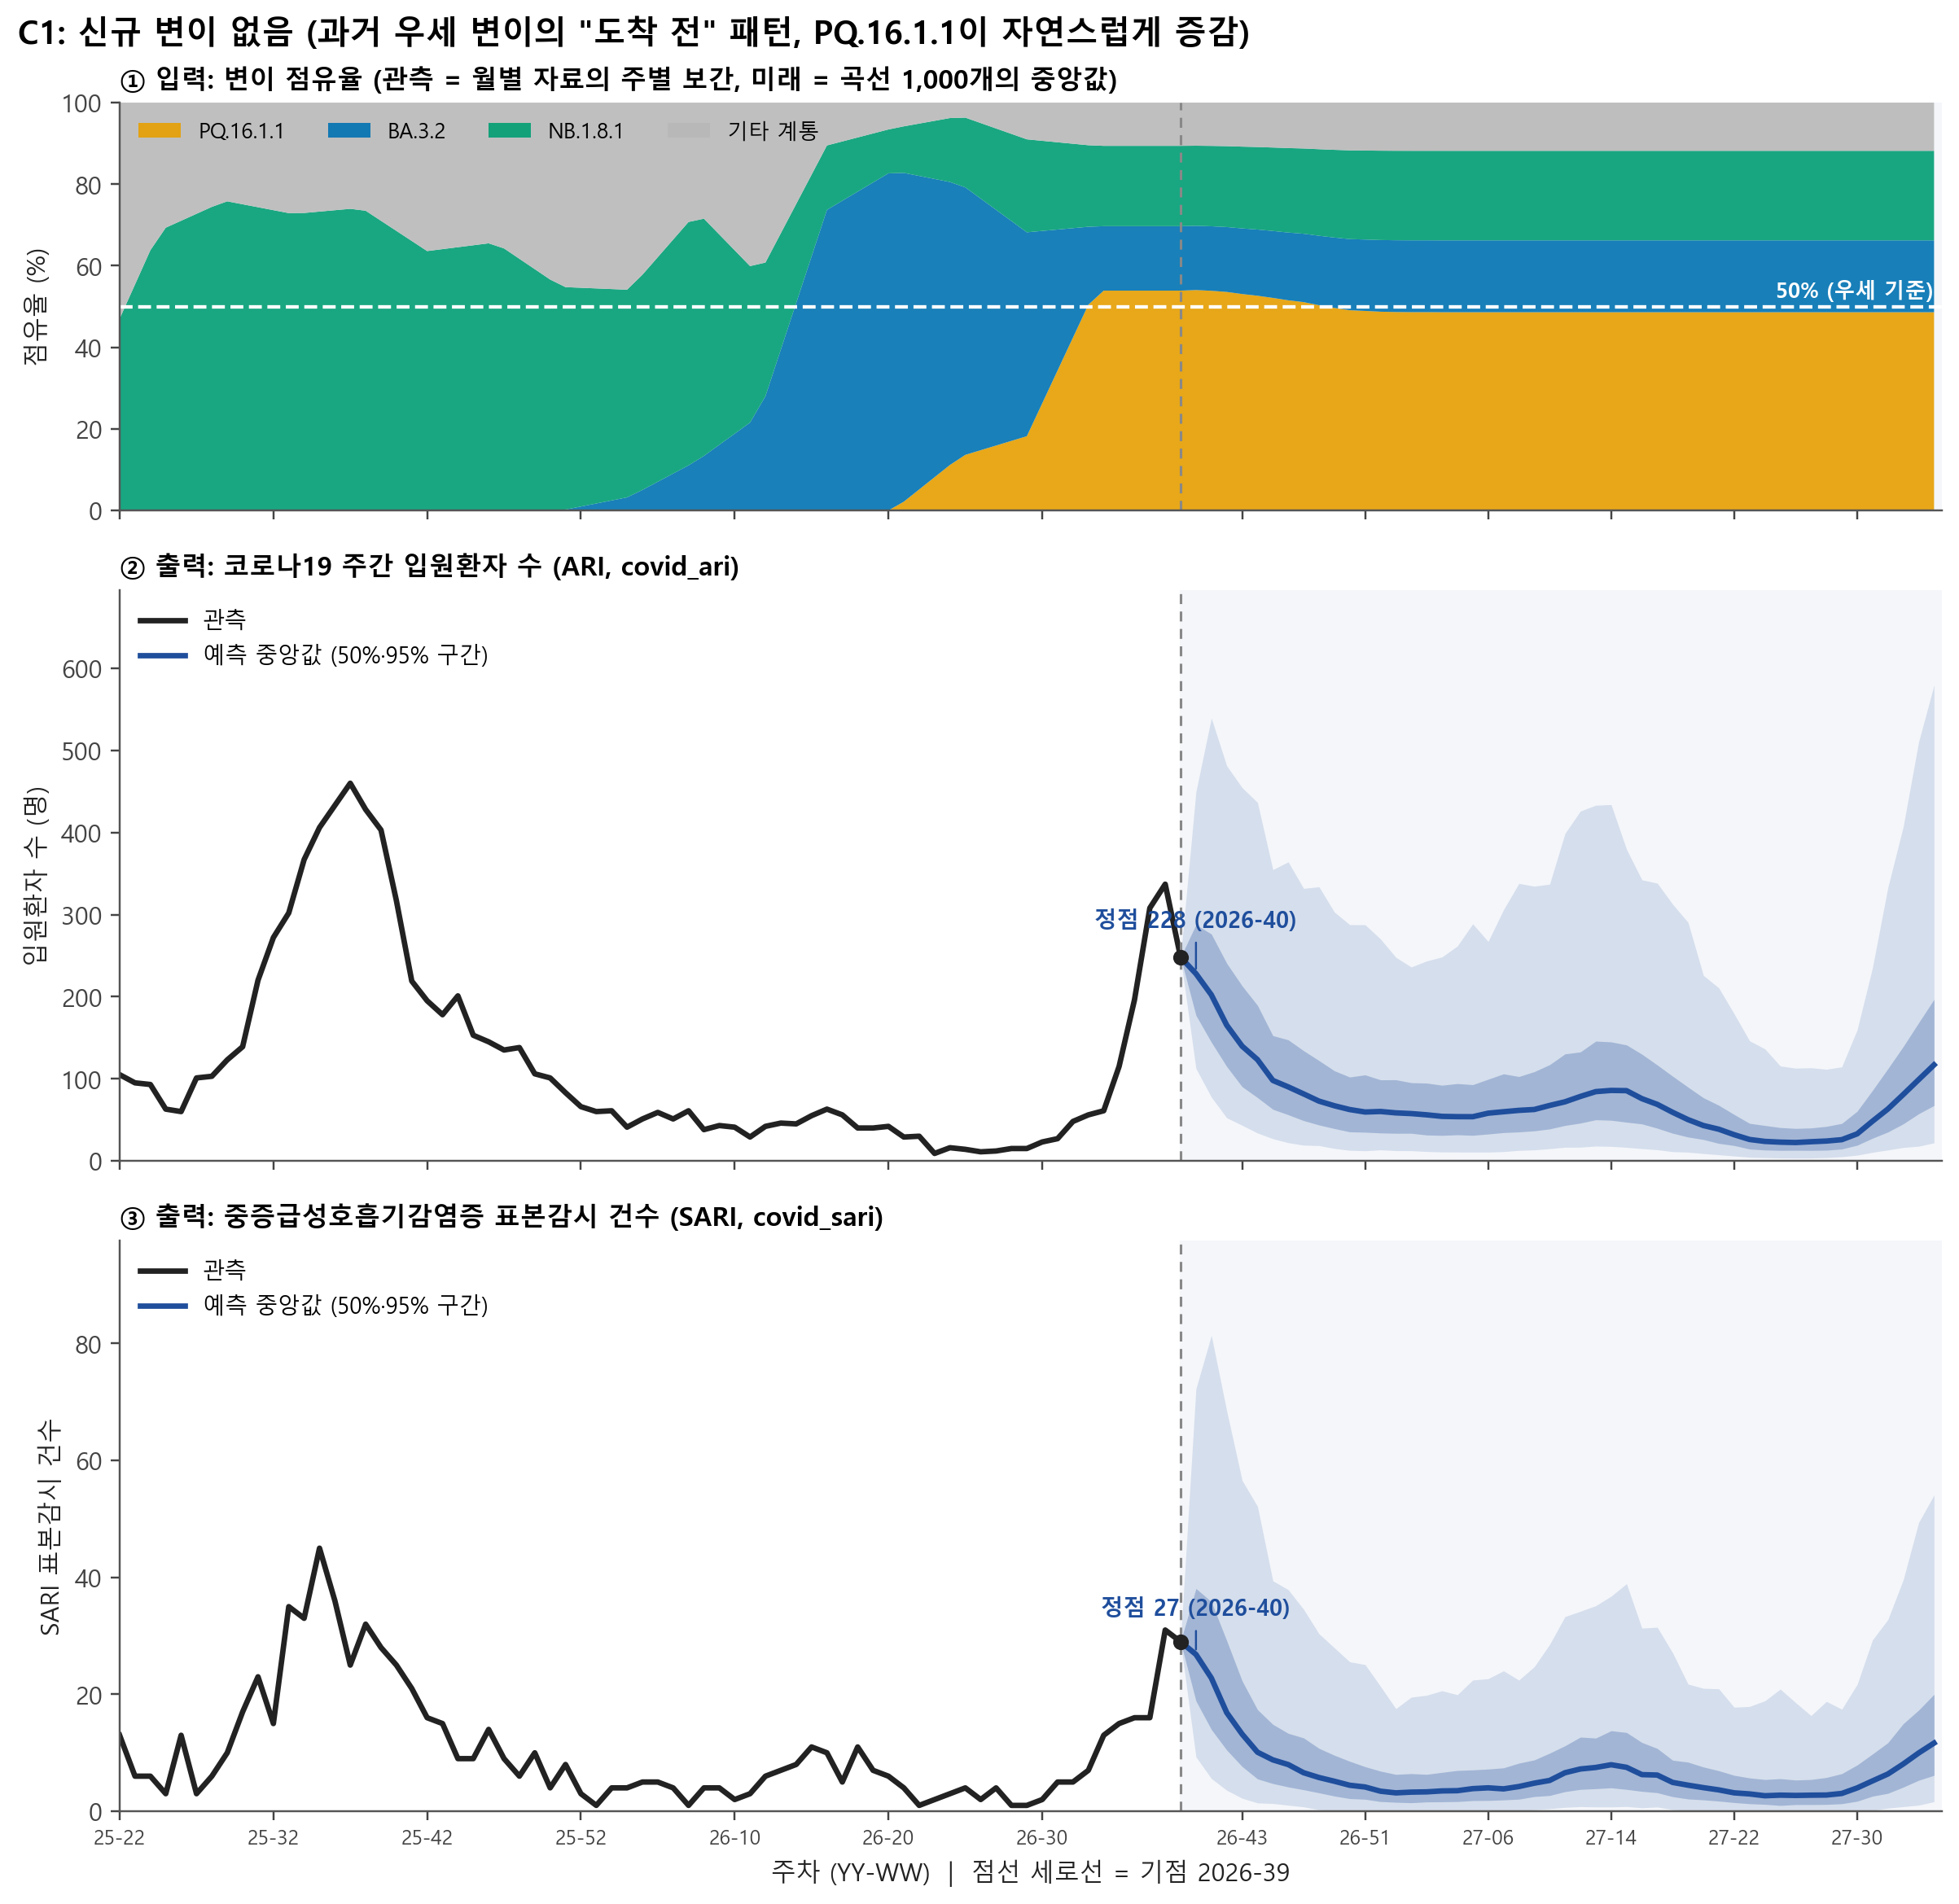

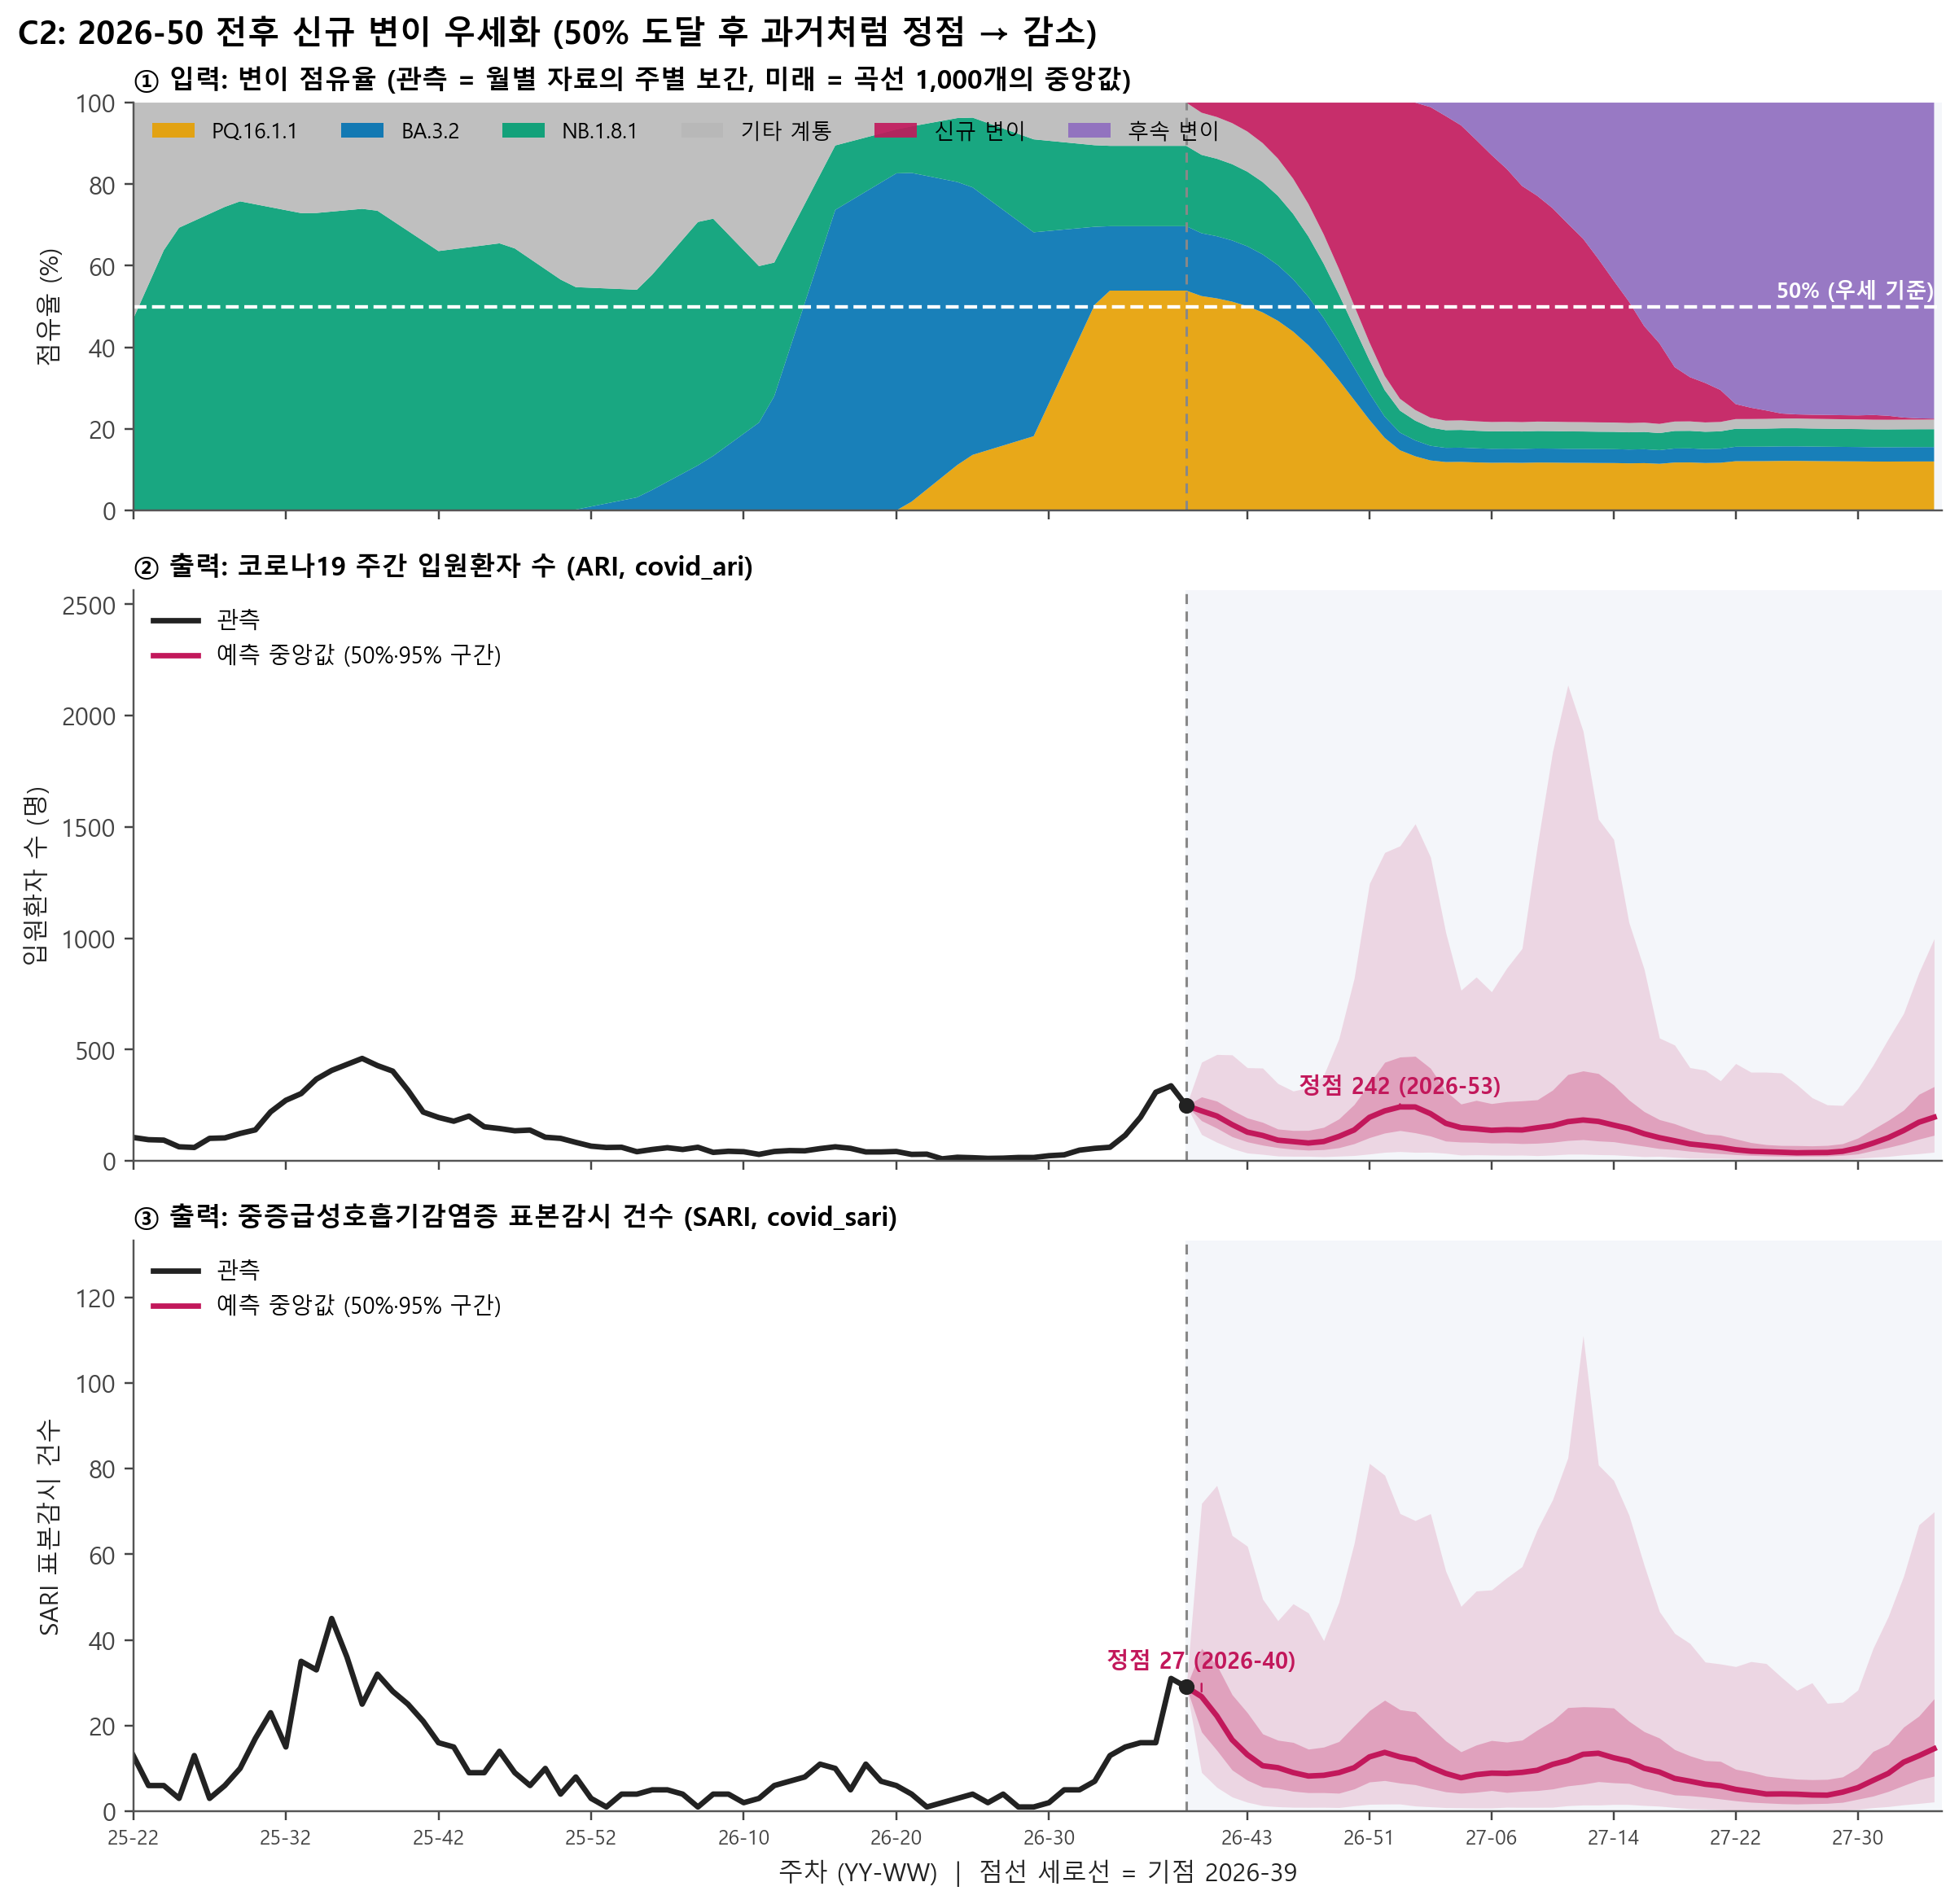

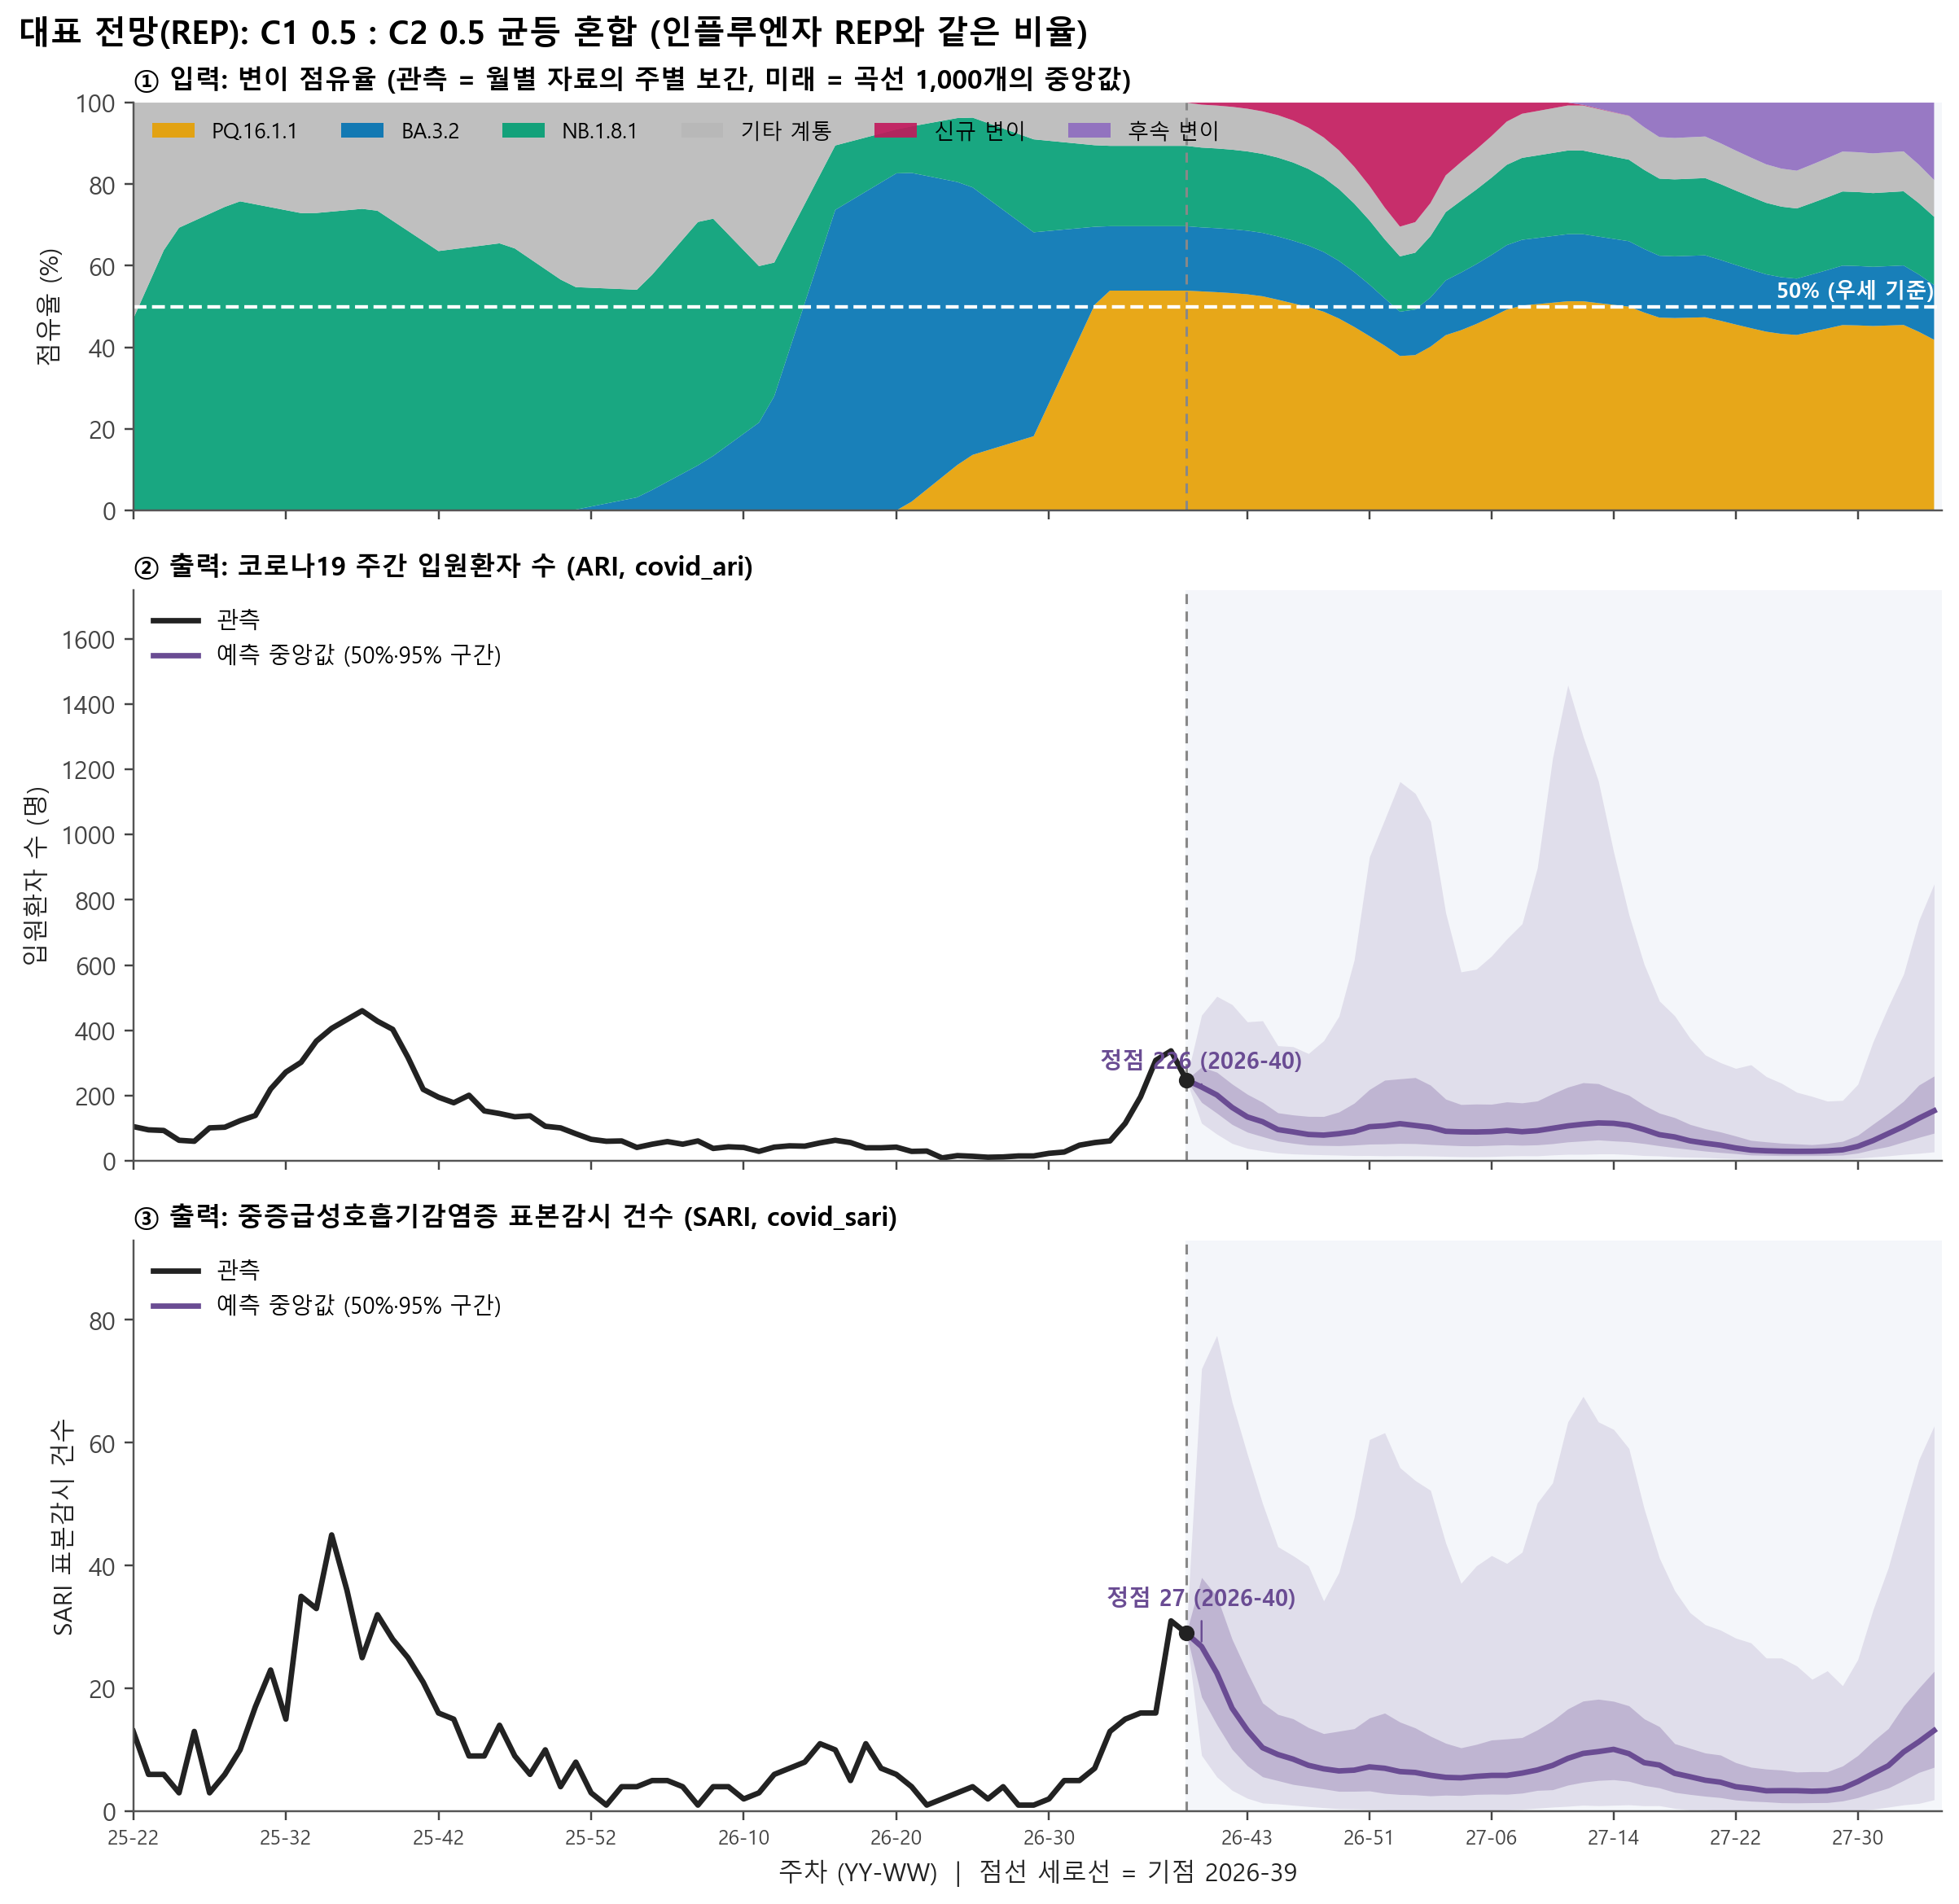

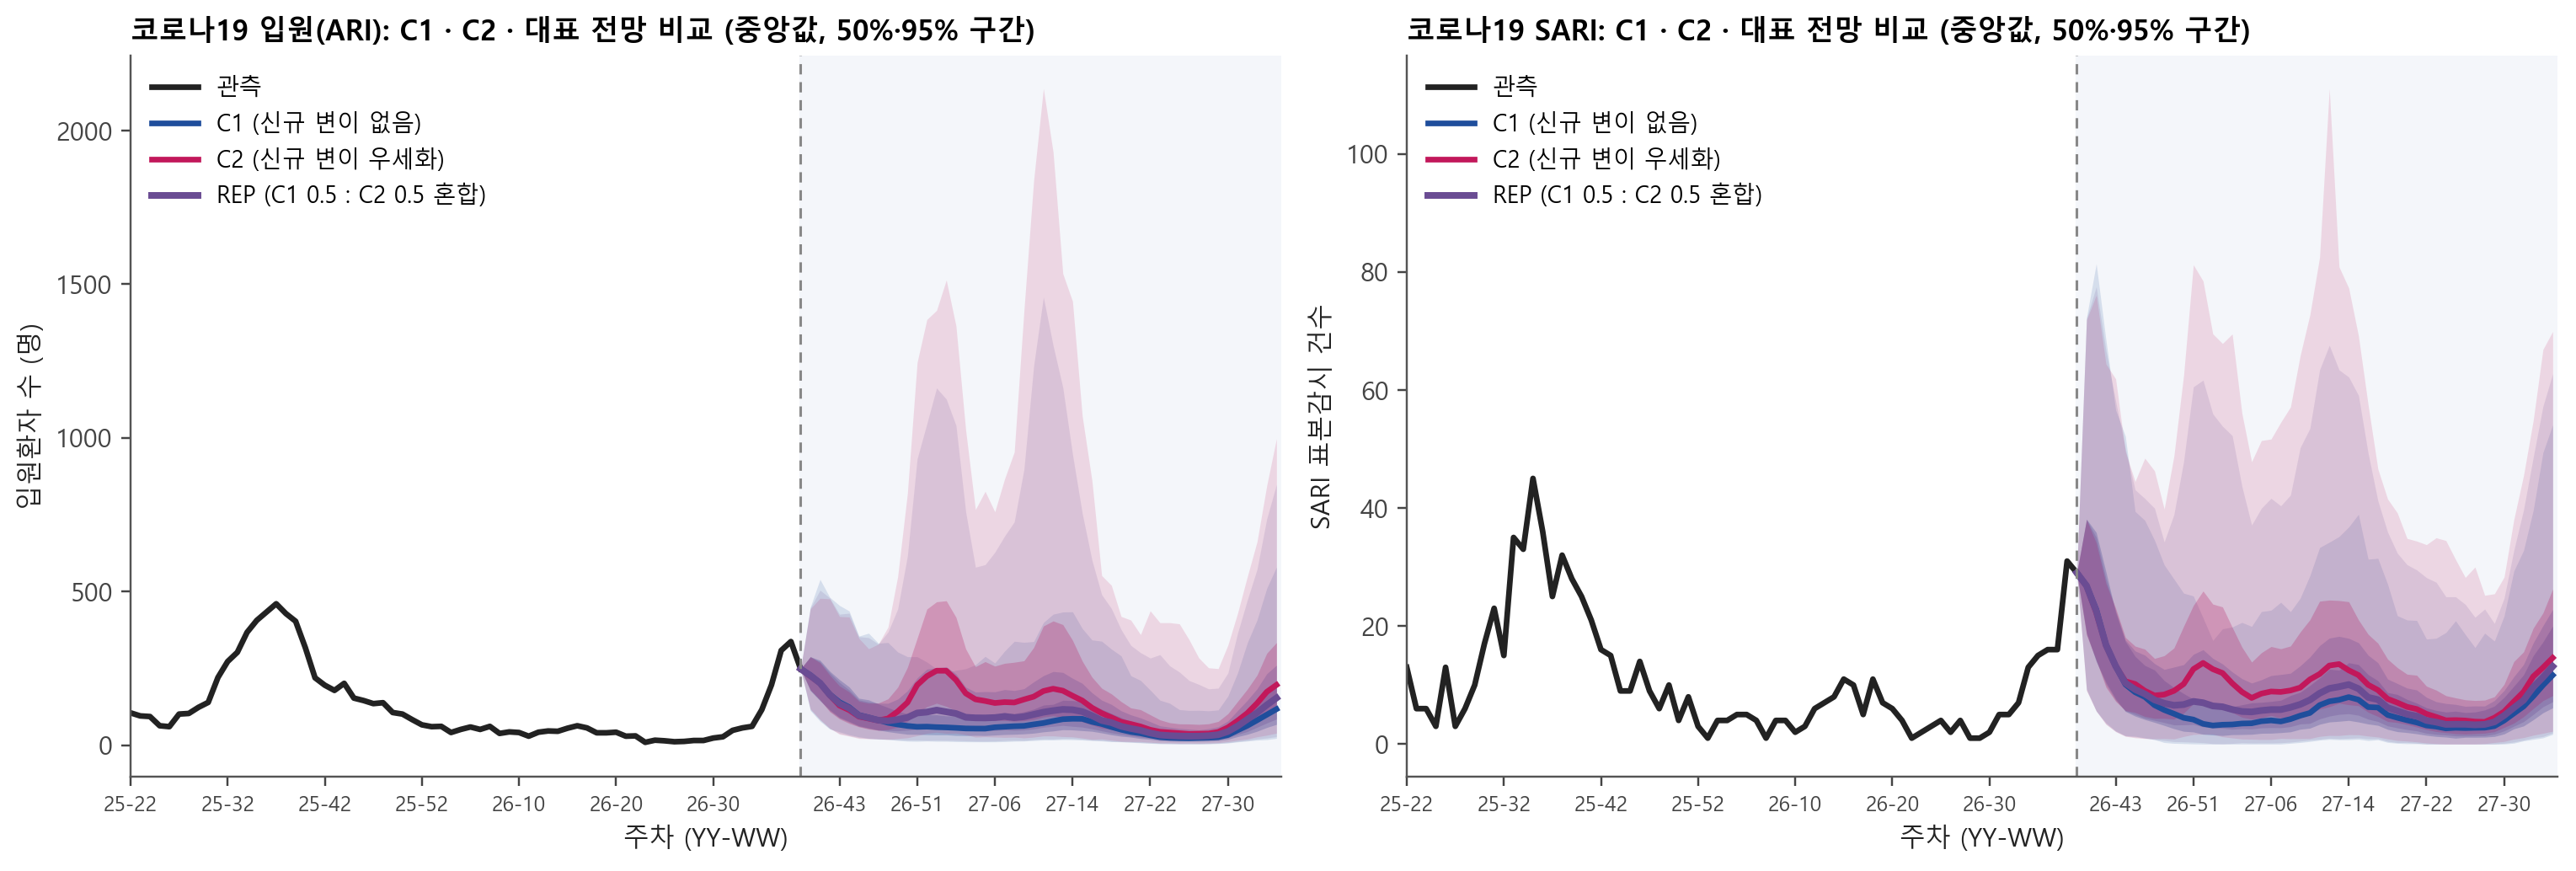

In [6]:
HIST_N = 70
hist = train.iloc[-HIST_N:]
x_hist = np.arange(-HIST_N + 1, 1)
x_fut = np.arange(1, N_STEPS + 1)
hist_labels = [f'{int(v) // 100 % 100}-{int(v) % 100:02d}' for v in hist['년주']]
fut_labels = [f'{s[2:4]}-{s[5:]}' for s in labels]
tick_x = list(range(-HIST_N + 1, 1, 10)) + list(range(4, N_STEPS + 1, 8))
tick_l = [hist_labels[t + HIST_N - 1] if t <= 0 else fut_labels[t - 1] for t in tick_x]
t_first = timeline.index(int(hist['년주'].iloc[0]))
COL.update({'REP': '#6A4C93', 'SUCC': '#8E6BBF'})
TITLE = {'C1': 'C1: 신규 변이 없음 (과거 우세 변이의 "도착 전" 패턴, PQ.16.1.1이 자연스럽게 증감)',
         'C2': 'C2: 2026-50 전후 신규 변이 우세화 (50% 도달 후 과거처럼 정점 → 감소)',
         'REP': '대표 전망(REP): C1 0.5 : C2 0.5 균등 혼합 (인플루엔자 REP와 같은 비율)'}


def style_axis(ax, ylabel):
    ax.axvline(0, color='#888888', linewidth=1.0, linestyle=(0, (4, 3)))
    ax.axvspan(0, N_STEPS + 0.5, color='#F4F6FA', zorder=0)
    ax.set_xticks(tick_x, tick_l, fontsize=8)
    ax.set_xlim(-HIST_N + 1, N_STEPS + 0.5)
    ax.set_ylabel(ylabel)


def fan(ax, paths, color, last, label=None, lw=2.2):
    x = np.r_[0, x_fut]
    for lo, hi, a in [(0.025, 0.975, 0.14), (0.25, 0.75, 0.28)]:
        ax.fill_between(x, np.r_[last, np.quantile(paths, lo, axis=0)], np.r_[last, np.quantile(paths, hi, axis=0)], color=color, alpha=a, linewidth=0)
    ax.plot(x, np.r_[last, np.median(paths, axis=0)], color=color, linewidth=lw, label=label)


def stack_shares(ax, sh_future):
    hist_sh = S_hist[t_first:t_first + HIST_N]
    fut = np.median(sh_future, axis=0)
    fut = fut / fut.sum(axis=1, keepdims=True)
    big = [pq, names.index('BA.3.2'), names.index('NB.1.8.1')]
    other_ids = [i for i in range(L) if i not in big]
    ys_h = [hist_sh[:, [i]].sum(axis=1) * 100 for i in big] + [hist_sh[:, other_ids].sum(axis=1) * 100, np.zeros(HIST_N), np.zeros(HIST_N)]
    ys_f = [fut[:, [i]].sum(axis=1) * 100 for i in big] + [fut[:, other_ids].sum(axis=1) * 100, fut[:, COL_NEW] * 100, fut[:, COL_SUCC] * 100]
    cols = [COL['PQ'], COL['BA32'], COL['NB'], COL['OTHER'], COL['NEW'], COL['SUCC']]
    lab = ['PQ.16.1.1', 'BA.3.2', 'NB.1.8.1', '기타 계통', '신규 변이', '후속 변이']
    keep = [i for i in range(6) if i < 4 or max(ys_f[i]) > 0.5]
    X = np.r_[x_hist, x_fut]
    Y = [np.r_[ys_h[i], ys_f[i]] for i in keep]
    ax.stackplot(X, *Y, colors=[cols[i] for i in keep], labels=[lab[i] for i in keep], alpha=0.9, linewidth=0)
    ax.axhline(50, color='white', linestyle='--', linewidth=1.4)
    ax.text(N_STEPS, 51, '50% (우세 기준)', color='white', ha='right', va='bottom', fontsize=8.5, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.legend(frameon=False, ncol=6, loc='upper left', fontsize=8.5)


OUT_PANELS = [('covid_ari', 'ARI', '입원환자 수 (명)', '② 출력: 코로나19 주간 입원환자 수 (ARI, covid_ari)'),
              ('covid_sari', 'SARI', 'SARI 표본감시 건수', '③ 출력: 중증급성호흡기감염증 표본감시 건수 (SARI, covid_sari)')]


def scenario_figure(sc, path):
    fig, axes = plt.subplots(3, 1, figsize=(11, 10.8), sharex=True, gridspec_kw={'height_ratios': [1, 1.4, 1.4]})
    stack_shares(axes[0], shares_sc[sc])
    axes[0].set_title('① 입력: 변이 점유율 (관측 = 월별 자료의 주별 보간, 미래 = 곡선 1,000개의 중앙값)', loc='left', fontsize=10.5, fontweight='bold')
    style_axis(axes[0], '점유율 (%)')
    for ax, (key, col, ylab, ttl) in zip(axes[1:], OUT_PANELS):
        ax.plot(x_hist, hist[col], color=COL['obs'], linewidth=2.2, label='관측')
        fan(ax, sim[(key, sc)], COL[sc], hist[col].iloc[-1], label='예측 중앙값 (50%·95% 구간)')
        ax.scatter([0], [hist[col].iloc[-1]], color=COL['obs'], s=28, zorder=5)
        med = np.median(sim[(key, sc)], axis=0)
        pk = int(np.argmax(med))
        ax.annotate(f'정점 {med[pk]:.0f} ({labels[pk]})', xy=(pk + 1, med[pk]), xytext=(pk + 1, med[pk] * 1.25), ha='center', fontsize=9, color=COL[sc], fontweight='bold', arrowprops=dict(arrowstyle='-', color=COL[sc], lw=0.8))
        ax.set_title(ttl, loc='left', fontsize=10.5, fontweight='bold')
        ax.set_ylim(0, max(float(np.quantile(sim[(key, sc)], 0.975, axis=0).max()), float(hist[col].max())) * 1.2)
        style_axis(ax, ylab)
        ax.legend(frameon=False, loc='upper left', fontsize=9)
    axes[2].set_xlabel('주차 (YY-WW)  |  점선 세로선 = 기점 2026-39')
    fig.suptitle(TITLE[sc], x=0.01, ha='left', fontsize=13, fontweight='bold')
    fig.tight_layout()
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)


for sc in ['C1', 'C2', 'REP']:
    scenario_figure(sc, RESULT_DIR / f'scenario_{sc}.png')
    display(Image(filename=str(RESULT_DIR / f'scenario_{sc}.png')))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (key, col, ylab, _) in zip(axes, OUT_PANELS):
    ax.plot(x_hist, hist[col], color=COL['obs'], linewidth=2.2, label='관측')
    for sc, lab in [('C1', 'C1 (신규 변이 없음)'), ('C2', 'C2 (신규 변이 우세화)'), ('REP', 'REP (C1 0.5 : C2 0.5 혼합)')]:
        fan(ax, sim[(key, sc)], COL[sc], hist[col].iloc[-1], label=lab, lw=2.6 if sc == 'REP' else 2.2)
    style_axis(ax, ylab)
    ax.set_title({'covid_ari': '코로나19 입원(ARI)', 'covid_sari': '코로나19 SARI'}[key] + ': C1 · C2 · 대표 전망 비교 (중앙값, 50%·95% 구간)', loc='left', fontweight='bold', fontsize=11)
    ax.legend(frameon=False, loc='upper left', fontsize=9)
    ax.set_xlabel('주차 (YY-WW)')
fig.tight_layout()
fig.savefig(RESULT_DIR / 'scenario_comparison.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(RESULT_DIR / 'scenario_comparison.png')))